In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("/content/drive/MyDrive/Finance_Club_Project/Dataset/train_dataset_final1.csv")

In [3]:
df.head()

,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,5017,2,0,2,60000,25.0,2,2,2,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,5018,2,1,1,290000,24.0,0,0,-2,-2,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,5019,1,0,2,180000,63.0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,5020,1,1,2,210000,43.0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,5021,2,0,1,280000,32.0,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [4]:
df['age'].fillna(df['age'].mean(), inplace = True)

/tmp/ipykernel_636/121903411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace = True)


In [5]:
df['marriage'] = df['marriage'].replace(0,3)
df['education'] = df['education'].replace([0,5,6],4)

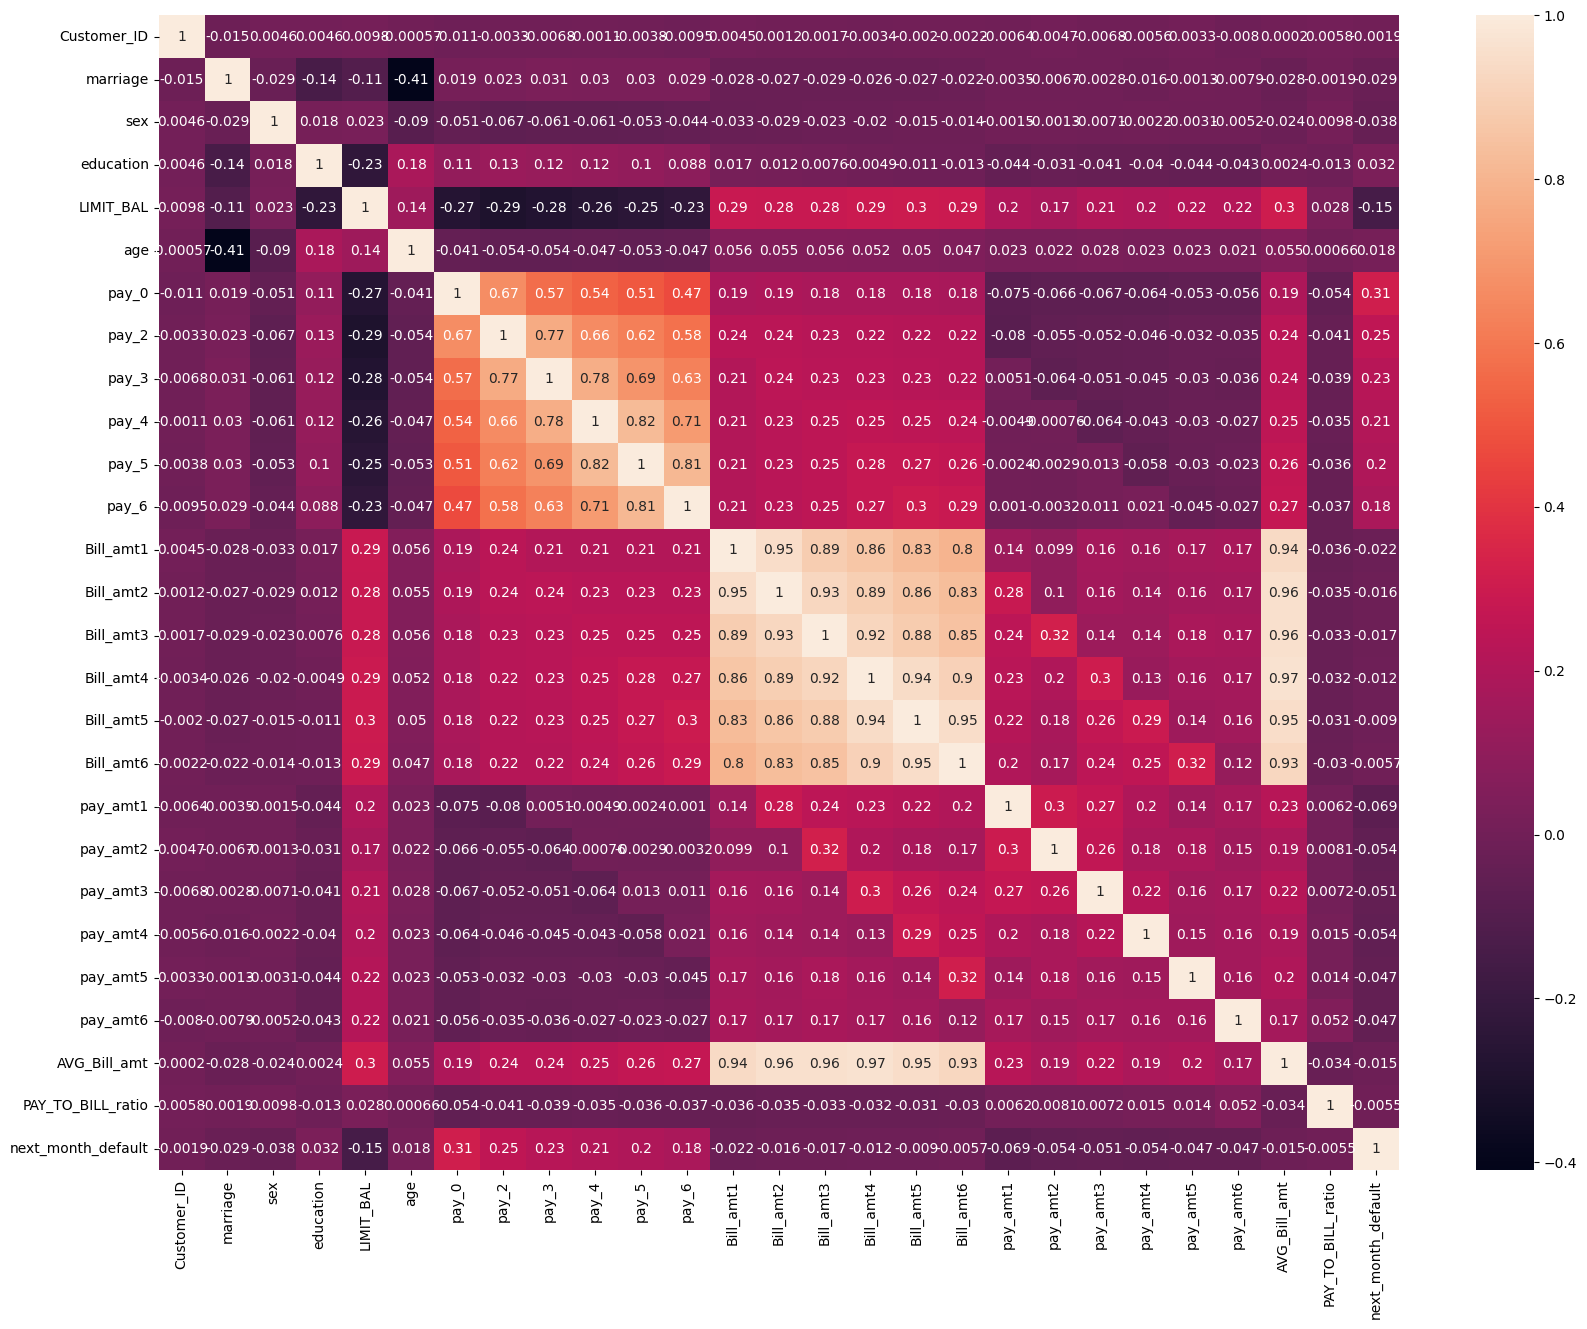

In [7]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [8]:
# CREDIT UTILIZATION RATIO
# Measures how much credit the customer is using compared to the limit.
df['credit_utilization'] = df['AVG_Bill_amt'] / (df['LIMIT_BAL'] + 1e-6)



# DELINQUENCY FEATURES
# How many months a customer was late in repayment.
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
df['delinquent_months'] = df[pay_cols].apply(lambda row: sum(row >= 1), axis=1)
df['max_delinquency'] = df[pay_cols].max(axis=1)
df['mean_delinquency'] = df[pay_cols].mean(axis=1)



# REPAYMENT GAP FEATURES
# Difference between bill and paid amount for each month.
for i in range(1, 7):
    df[f'diff_amt_{i}'] = df[f'Bill_amt{i}'] - df[f'pay_amt{i}']



# Summary statistics for repayment gap
df['avg_payment_gap'] = df[[f'diff_amt_{i}' for i in range(1, 7)]].mean(axis=1)
df['total_payment_gap'] = df[[f'diff_amt_{i}' for i in range(1, 7)]].sum(axis=1)



# PAYMENT CONSISTENCY
pay_amt_cols = [f'pay_amt{i}' for i in range(1, 7)]
df['payment_std'] = df[pay_amt_cols].std(axis=1)
df['payment_mean'] = df[pay_amt_cols].mean(axis=1)
df['payment_cv'] = df['payment_std'] / (df['payment_mean'] + 1e-6)



# RECENT-WEIGHTED DELINQUENCY SCORE
pay_cols_weighted = [f'pay_{i}' for i in [0, 2, 3, 4, 5, 6]]
weights = [6, 5, 4, 3, 2, 1]
df['weighted_pay_score'] = df[pay_cols_weighted].mul(weights, axis=1).sum(axis=1)



# BILL & PAYMENT TRENDS
from scipy.stats import linregress

def get_slope(row):
    return linregress(range(1, 7), row).slope

df['bill_trend'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].apply(get_slope, axis=1)
df['pay_trend'] = df[[f'pay_amt{i}' for i in range(1, 7)]].apply(get_slope, axis=1)



# DEMOGRAPHIC RISK INTERACTIONS
df['age_to_limit'] = df['age'] / (df['LIMIT_BAL'] + 1e-6)
df['marriage_education'] = df['marriage'].astype(str) + '_' + df['education'].astype(str)



# OPTIONAL CLEAN-UP
diff_cols = [f'diff_amt_{i}' for i in range(1, 7)]
df.drop(columns=diff_cols, inplace=True)


In [9]:
df.head()

,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,avg_payment_gap,total_payment_gap,payment_std,payment_mean,payment_cv,weighted_pay_score,bill_trend,pay_trend,age_to_limit,marriage_education
0,5017,2,0,2,60000,25.0,2,2,2,0,...,40185.313333,241111.88,714.956931,1326.185000,0.539108,30,-9752.770000,76.776286,0.000417,2_2
1,5018,2,1,1,290000,24.0,0,0,-2,-2,...,1860.078333,11160.47,1129.473118,674.998333,1.673298,-16,-1169.548571,269.948286,0.000083,2_1
2,5019,1,0,2,180000,63.0,0,0,0,0,...,48412.396667,290474.38,123.925072,2009.286667,0.061676,0,998.838286,-31.773714,0.000350,1_2
3,5020,1,1,2,210000,43.0,0,0,0,0,...,83154.838333,498929.03,337.634028,3074.916667,0.109803,0,-3253.982000,-140.201714,0.000205,1_2
4,5021,2,0,1,280000,32.0,-2,-2,-2,-2,...,3261.886667,19571.32,17912.037141,8552.366667,2.094395,-42,-1522.201714,-1642.400571,0.000114,2_1


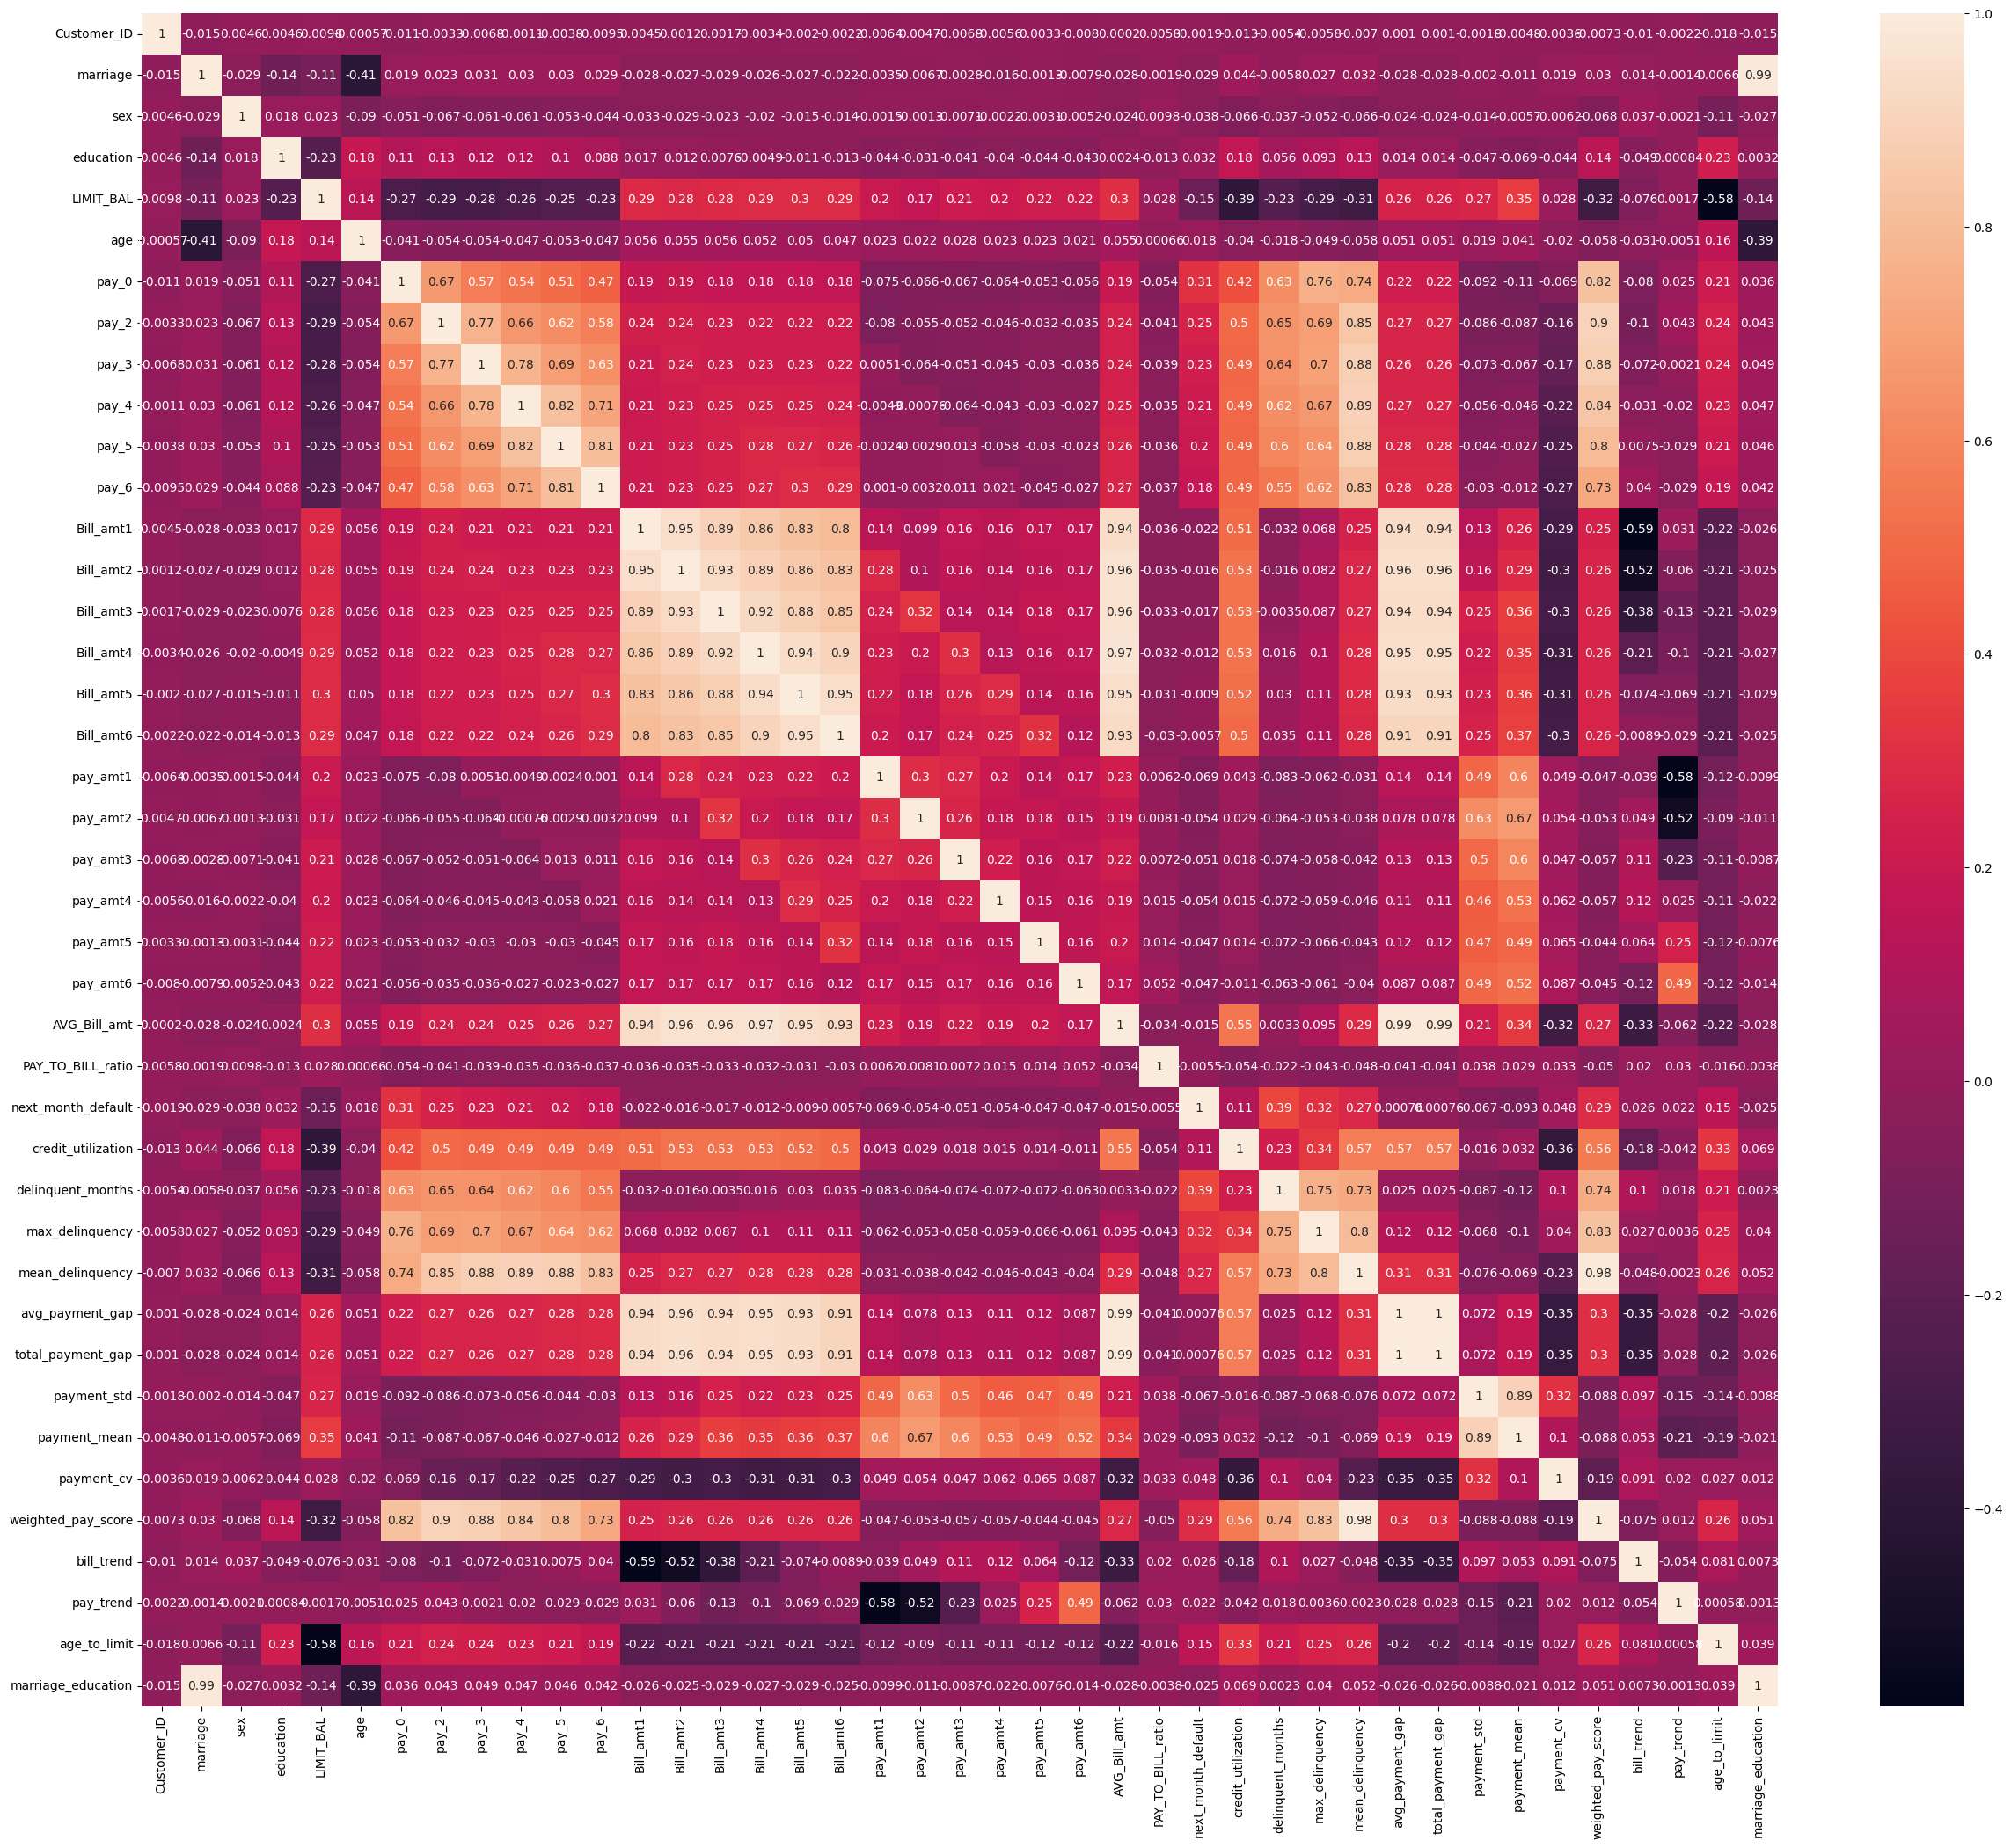

In [10]:
plt.figure(figsize=(30,25))
sns.heatmap(df.corr(), annot=True)
plt.show()

# Class Imbalance and Feature Selection

In [11]:
# Importing SMOTE for handling imbalanced classes
from imblearn.over_sampling import SMOTE

# Creating SMOTE object
oversampler = SMOTE()

# Selecting features (excluding target)
features = df.drop(columns=['next_month_default'])
target = df['next_month_default']

# Applying SMOTE to balance the dataset
balanced_features, balanced_target = oversampler.fit_resample(features, target)

# Displaying dataset shapes before and after resampling
print("Original dataset size:", df.shape[0])
print("Balanced dataset size:", balanced_target.shape[0])


Original dataset size: 25247
Balanced dataset size: 40880


In [12]:
# Create a DataFrame from the resampled features
feature_columns = df.drop(columns=['next_month_default']).columns
balanced_df = pd.DataFrame(balanced_features, columns=feature_columns)

In [13]:
balanced_df['next_month_default'] = balanced_target

In [14]:
balanced_df.shape

(40880, 41)

In [15]:
X = balanced_df[[col for col in balanced_df.columns if col != 'next_month_default']]
y = balanced_df['next_month_default']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
print('Train Size : ', X_train.shape)
print('Test Size : ', X_test.shape)

Train Size :  (32704, 40)
Test Size :  (8176, 40)


In [17]:
from sklearn.ensemble import RandomForestClassifier

Featureselection = RandomForestClassifier(n_estimators=100, random_state=0)
Featureselection.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [18]:
score_Feature = pd.Series(Featureselection.feature_importances_, index=X_train.columns).sort_values(ascending=False)
score_Feature

,0
mean_delinquency,0.103943
weighted_pay_score,0.075427
marriage_education,0.066951
max_delinquency,0.038357
pay_0,0.031349
pay_2,0.027581
payment_mean,0.026513
credit_utilization,0.024903
delinquent_months,0.024524
Bill_amt1,0.024484


In [19]:
selected_features = [
    'mean_delinquency', 'weighted_pay_score', 'marriage_education', 'max_delinquency',
    'pay_0', 'credit_utilization', 'pay_2', 'Bill_amt1',
    'payment_mean', 'AVG_Bill_amt', 'delinquent_months', 'pay_amt2',
    'pay_amt1', 'pay_3', 'age_to_limit', 'Bill_amt2',
    'payment_cv', 'pay_amt3', 'bill_trend', 'payment_std'
]

In [20]:
balanced_df.to_csv("/content/drive/MyDrive/Finance_Club_Project/Dataset/processed_data.csv",index=False)